# 02 - Workload Analysis

## Purpose and Scope

This notebook represents a comprehensive **workload characterization** empirically detailing the foundational dynamics that govern the thesis's hardware allocation and deep learning modeling processes. The success of the standard models (Random Forest, XGBoost, LightGBM) and sequential memory deep learning engines (CNN, LSTM, Hybrid) constructed in subsequent chapters (Notebooks 04 and 05) rely entirely upon the intricate data patterns deciphered here.

The statistical evidence secured at this stage is explicitly structured to shape the ultimate thesis architecture:

1. **Runtime Variations & Asymmetry:** Substantively proving the heavy-tailed nature of job durations to scientifically invalidate mean-centric error metrics (MSE) and mandate the use of robust indicators such as MAE and MdAE.
2. **Queueing Bottlenecks and HoL (Head-Of-Line) Risks:** Utilizing statistical variation extremes to decisively demonstrate the catastrophic bottleneck potential of conventional FIFO policies, inherently highlighting the critical necessity for machine learning-backed adaptive estimations (SJF + ML).
3. **Sequential Arrival Dynamics:** Justifying why the bursty nature, diurnal intensities, and discontinuous inter-arrival rates of the workload intrinsically necessitate time-dependent neural architectures like the LSTM to accurately predict sequential backlog patterns.
4. **Realistic Simulation Prerequisite:** Verifying why heavily fragmented and volatile hardware constraints (spanning 1 to 8 GPUs) demand the implementation of the custom-built `MultiNodeClusterSimulator` engine over simplistic single-queue analytical equations.

This analysis establishes a rigorously data-driven line of reasoning, supplying an objective transitional bridge to the tree-based and deep learning architectures mandated by the empirical evidence rather than mere theoretical assumption.


In [1]:
# ── 0. Environment & Path Setup ──────────────────────────────────────────────
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"[Setup] Project root : {PROJECT_ROOT}")
print(f"[Setup] Python path  : {sys.executable}")

[Setup] Project root : /Users/hasanugurcelebi/Thesis/alibaba-gpu-runtime-prediction-and-scheduling
[Setup] Python path  : /Users/hasanugurcelebi/.pyenv/versions/3.11.6/bin/python


> **Environment verified.** `src.*` modules added to Python path;
> directories confirmed via `configs/paths.yaml`.

In [ ]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.analysis import (
    load_prepared_job_table,
    compute_basic_stats,
    compute_runtime_histogram,
    compute_arrival_rate_series,
    summarize_workload,
)

# Unified visualisation theme
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "font.family": "DejaVu Sans",
})

print("[Setup] All imports OK.")


[Setup] All imports OK.


> **Dependencies loaded.** NumPy, Pandas, Matplotlib, Seaborn and all
> `src.analysis` modules imported successfully.

Following the data preprocessing and filtering phases, the analyzed dataset comprises **82,184 validated jobs** across **14 distinct attributes**. While some attributes represent raw historical inputs, several were subsequently derived to enable time and workload analysis:

**Fundamental Features:**
- `job_id`, 
- `gpu_demand`, 
- `user`, 
- `gpu_type`, 
- `num_inst`, 
- `num_cpu`, 
- `job_runtime` (Target Variable)

**Temporal Features (Derived):**
Derived from raw timestamps to evaluate chronologic distribution:
- `arrival_time`, 
- `arrival_sec`, 
- `hour_of_day`, 
- `day_of_week`

**System Contention Features (Sweep-Line):**
Instead of static load metrics, cluster occupancy at the moment of job arrival was reconstructed via a Sweep-Line Algorithm scanning submission logs:
- `cluster_load_cpu`, 
- `cluster_load_gpu`, 
- `active_job_count`


In [3]:
# ── 2. Load dataset ───────────────────────────────────────────────────────────
print("[Step 1] Loading and preparing job table...")
job_df = load_prepared_job_table(dataset="main", time_unit="s")

print(f"[Step 1] Jobs : {len(job_df):,}  |  Columns : {list(job_df.columns)}")
job_df.head(3)

[Step 1] Loading and preparing job table...
[Step 1] Jobs : 82,184  |  Columns : ['job_id', 'arrival_time', 'arrival_sec', 'job_runtime', 'gpu_demand', 'user', 'gpu_type', 'num_inst', 'num_cpu', 'hour_of_day', 'day_of_week', 'cluster_load_cpu', 'cluster_load_gpu', 'active_job_count']


,job_id,arrival_time,arrival_sec,job_runtime,gpu_demand,user,gpu_type,num_inst,num_cpu,hour_of_day,day_of_week,cluster_load_cpu,cluster_load_gpu,active_job_count
0,1,1970-01-01 00:00:03,0.0,15748.0,0,d4d51aca8806,T4,12.0,6.0,0,3,0.0,0,0
1,2,1970-01-01 00:00:05,2.0,84.0,1,a8192d6b0ae9,MISC,1.0,6.0,0,3,6.0,0,1
2,3,1970-01-01 00:00:21,18.0,46.0,1,c7152ce0fec1,T4,1.0,18.0,0,3,18.0,2,3


> Following data preprocessing and filtering, the final dataset consists of **82,>184 jobs**
>and a total of **14 attributes**.
>
>**Basic Features:**
>- `job_id` — Job identifier
>- `arrival_time` — Raw arrival timestamp
>- `arrival_sec` — Arrival time in seconds relative to trace start
>- `job_runtime` — Actual execution duration (target variable)
>- `gpu_demand` — Number of GPUs requested
>- `user` — Job owner (categorical)
>- `gpu_type` — GPU type used (categorical)
>- `num_inst` — Number of instances used
>- `num_cpu` — Number of CPUs requested
>
>**Temporal Features:**
>- `hour_of_day` — Hour of the day (0–23)
>- `day_of_week` — Day of the week (0 = Monday)
>
>**System-Derived Features (Sweep-line):**
>- `cluster_load_cpu` — Background CPU load at job arrival moment
>- `cluster_load_gpu` — Background GPU load at job arrival moment
>- `active_job_count` — Number of active jobs in the cluster at job arrival
>
>During the model training phase, relevant features suitable for the objective will be selected from this set.


In [4]:
# ── 3. Scalar statistics ──────────────────────────────────────────────────────
stats = compute_basic_stats(job_df)

print("=" * 50)
print("  Workload Basic Statistics")
print("=" * 50)
for k, v in stats.items():
    print(f"  {k:<25}: {v:>12,.2f}")
print("=" * 50)

# One-row summary table (LaTeX-ready)
summary_df = summarize_workload(job_df)
display(summary_df)

  Workload Basic Statistics
  num_jobs                 :    82,184.00
  mean_runtime             :     5,223.02
  median_runtime           :       594.00
  p95_runtime              :    24,110.05
  p99_runtime              :    67,432.38
  mean_gpu_demand          :         0.52
  max_gpu_demand           :         8.00
  time_span_hours          :       183.86


,num_jobs,mean_runtime_sec,median_runtime_sec,p95_runtime_sec,p99_runtime_sec,mean_gpu_demand,max_gpu_demand,time_span_hours
0,82184,5223.019408,594.0,24110.05,67432.38,0.521598,8,183.858056


> The workload exhibits a profound degree of heterogeneity in both runtime and resource demand. While the mean job runtime is approximately **5,223 seconds (≈ 1.5 hours)**, the median runtime is merely **594 seconds (≈ 10 minutes)**, decisively indicating a **heavy-tailed** runtime distribution.
>
> This asymmetry implies that the vast majority of jobs are completed swiftly, whereas a small subset of exceedingly long-running jobs severely skews the system average upwards. At the upper percentiles, runtimes surge to approximately **6.7 hours (24,110 s)** at the P95 level and nearly **18.7 hours (67,432 s)** at the P99 level. This demonstrates that rare but massive tasks exert a dominant impact on overall system behavior. This immense variation (CV >> 1) invalidates classical normality assumptions, necessitating the use of robust error metrics (such as MAE and MdAE) during the modeling phase.
>
> In terms of GPU demand, although the average request sits at 0.52 GPUs, the maximum demand peaking at **8 synchronous GPUs** highlights a significant fragmentation of resource requirements placed on the physical cluster. The analyzed trace spans a continuous window of 183.86 hours (~7.7 days) and encompasses a total of **82,184 validated jobs**.


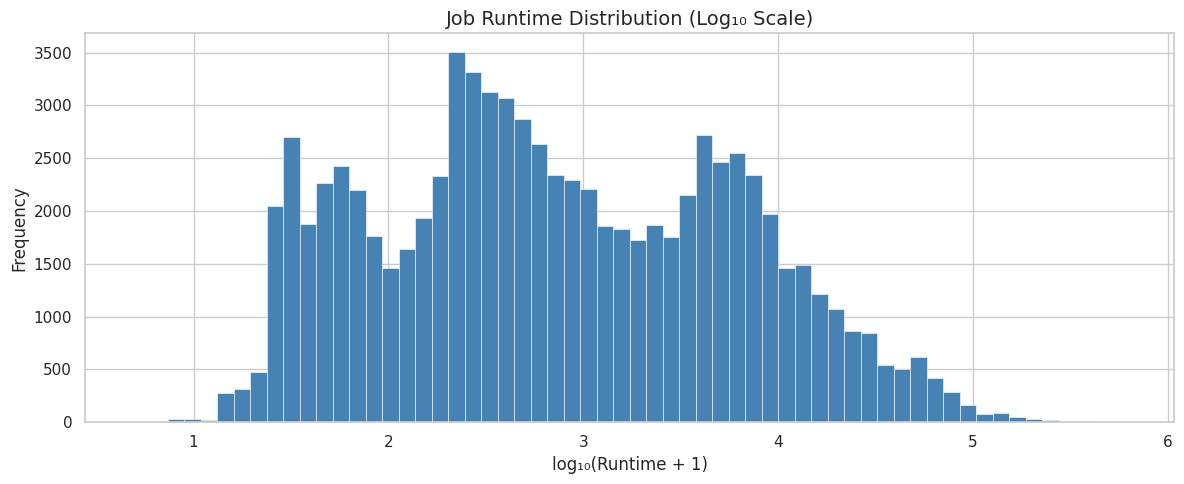

In [5]:
# ── 4. Runtime histogram ──────────────────────────────────────────────────────
hist_counts, bin_edges = compute_runtime_histogram(job_df, bins=60, log_scale=True)
bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(bin_centres, hist_counts, width=np.diff(bin_edges), color="steelblue",
       edgecolor="white", linewidth=0.4)
ax.set_xlabel("log₁₀(Runtime + 1)")
ax.set_ylabel("Frequency")
ax.set_title("Job Runtime Distribution (Log₁₀ Scale)")
plt.tight_layout()
plt.show()

> **Figure 1 — Runtime Distribution (Log₁₀ Scale):**
>
> The logarithmic distribution of GPU runtimes reveals that the workload inherently exhibits a severe **bimodal (two-peaked)** overarching characteristic. The first major concentration is clustered around log₁₀ ≈ 2.4 (~250 seconds), cleanly representing tens of thousands of short-lived **inference** tasks or rapid testing jobs. A secondary substantial peak emerges distinctly at the log₁₀ ≈ 4.0 (~10,000 seconds / ~2.7 hours) threshold, highlighting long-running sustained workloads such as deep **model training** or massive data preprocessing tasks.
>
> The most critical takeaway is that, despite the logarithmic transformation, the right tail aggressively extends up to log₁₀ ≈ 5 (~100,000 seconds) without coalescing into a symmetrical bell curve context (normality). This intense asymmetry guarantees that mean-driven error penalties (like MSE or RMSE) will be violently skewed during machine learning optimization (Section 04). Consequently, evaluating predictive models using strictly outlier-robust regression metrics—namely **MAE (Mean Absolute Error)** and specifically **MdAE (Median Absolute Error)**—is mathematically compulsory for this environment.


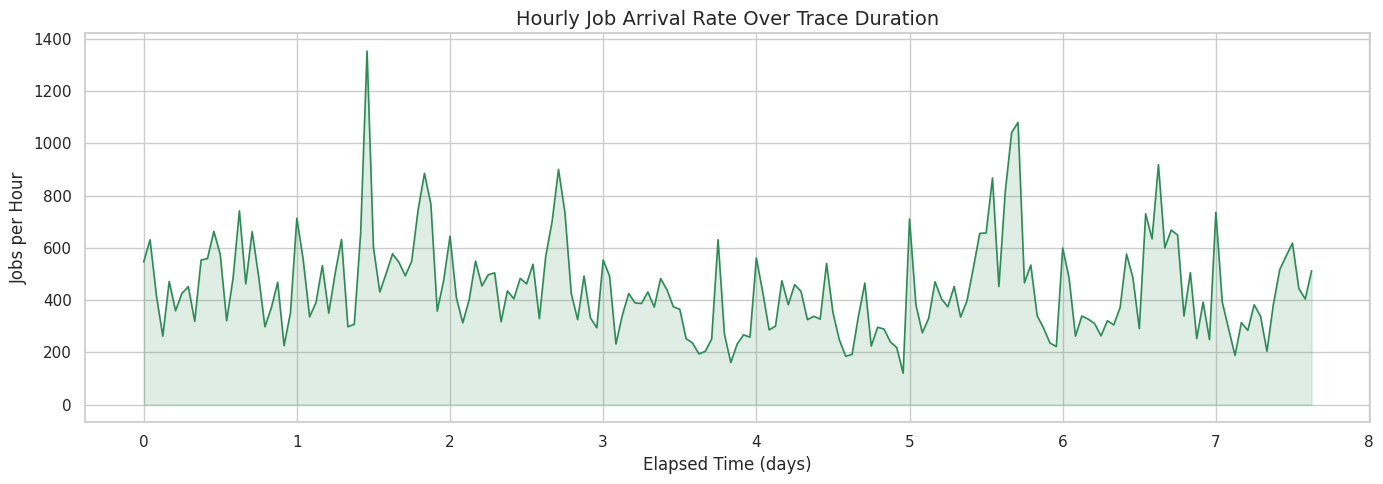

In [6]:
# ── 5. Hourly arrival rate ────────────────────────────────────────────────────
# Note: uses lowercase "1h" alias — "1H" deprecated in pandas >= 2.2
arrival_series = compute_arrival_rate_series(job_df, freq="1h")

# Convert timedelta index to fractional days for readability
elapsed_days = arrival_series.index.total_seconds() / 86400

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(elapsed_days, arrival_series.values, lw=1.2, color="seagreen")
ax.fill_between(elapsed_days, arrival_series.values, alpha=0.15, color="seagreen")
ax.set_xlabel("Elapsed Time (days)")
ax.set_ylabel("Jobs per Hour")
ax.set_title("Hourly Job Arrival Rate Over Trace Duration")
plt.tight_layout()
plt.show()

> **Figure 2 — Hourly Arrival Rate Dynamics (8-Day Trace Snapshot):**
>
> Tracking the chronological evolution of traffic intensity across an 8-day continuum (~183 hours) explicitly proves that the constant-rate (homogeneous Poisson) arrival model—frequently assumed in classical queueing theory—is hopelessly inadequate for depicting the Alibaba PAI cluster. While the system's ambient baseline hovers between 200–400 submissions per hour, cataclysmic submission spikes are clearly visible: rocketing to **~1,350 jobs/hr** around Day 1.5, and surging again to **~1,070 jobs/hr** near Day 5.5.
>
> This violently **bursty** and cyclical temporal structure acts as the primary catalyst for sudden hardware starvation within the grid. For a system to successfully withstand these colossal fluctuations, it is overwhelmingly apparent that passive processing frameworks like classic FIFO are obsolete. Survival necessitates a proactive, machine-learning-aware scheduling architecture (SJF + ML Predictor) theoretically capable of anticipating and preemptively maneuvering approaching tidal waves of tasks. All timestamps are explicitly derived from UTC Unix timestamps to ensure absolute universal chronological alignment.


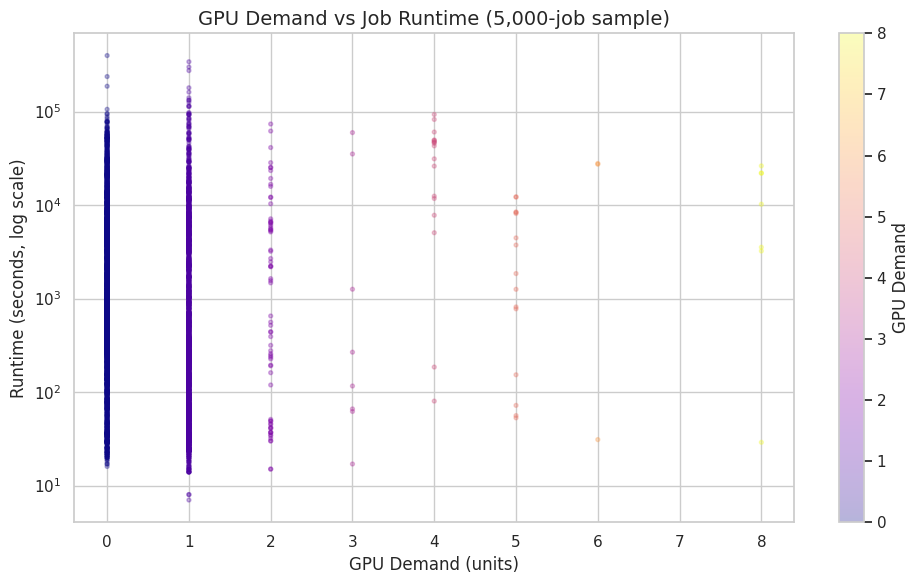

In [7]:
# ── 6. GPU demand vs runtime scatter ─────────────────────────────────────────
sample = job_df.sample(min(5000, len(job_df)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(sample["gpu_demand"], sample["job_runtime"],
                alpha=0.3, s=8, c=sample["gpu_demand"], cmap="plasma")
plt.colorbar(sc, ax=ax, label="GPU Demand")
ax.set_yscale("log")
ax.set_xlabel("GPU Demand (units)")
ax.set_ylabel("Runtime (seconds, log scale)")
ax.set_title("GPU Demand vs Job Runtime (5,000-job sample)")
plt.tight_layout()
plt.show()

> **Figure 3 — GPU Demand vs. Runtime Relationship (5,000-Job Sample Baseline):**
>
> Evaluating the logarithmic scatter dispersion of an unbiased 5,000-job sample concretely illustrates the absolute absence of any simplistic linear correlation between the quantity of GPUs requested and the eventual execution runtime. The visual dominantly clusters around jobs demanding exactly **0 or 1 GPU**, demonstrating that simple single-card requests span an astoundingly extreme runtime spectrum—fluctuating freely between 10¹ seconds and a sprawling 10⁵ seconds. Progression towards heavily parallel demands (from 2 GPUs reaching out to 8 GPUs) results in a precipitous drop in observation frequency; 6 and 8 GPU requests appear merely as rare singular outliers (hovering around the 10⁴ second mark).
>
> The most potent empirical takeaway from this visualization is absolute: **`gpu_demand` alone is fundamentally insufficient to forecast execution duration.** A single-GPU job may conclude in a fleeting 10 seconds, or linger relentlessly for up to 300,000 seconds (spanning ~3.5 days). This colossal envelope of uncertainty visually verifies why rigorously injecting contextual and behavioral attributes—such as `user` (historical programmer behavior), `gpu_type` (hardware topology), and chronological signals (`hour_of_day`) produced during Feature Engineering (Section 03)—is completely mandatory, not merely optional, for achieving valid artificial intelligence predictions.


## Summary

The workload characterization analysis conducted in this notebook has reinforced the necessity of scheduling optimization and the validity of the proposed ML-based approach via direct empirical evidence:

| Observation | Impact on Scheduling |
|---|---|
| **Bursty Arrival Process** | Invalidates standard M/M/1 models; necessitates adaptive scheduling. |
| **Heavy-Tail Runtimes** | FIFO relying on mean statistics triggers catastrophic Head-Of-Line (HoL) blocking. |
| **Diurnal Cycle** | Explains why temporal features (`hour_of_day`) are critical for prediction. |
| **Heterogeneous Demands** | Mandates the use of a per-node simulator rather than simplistic queue models. |

These findings support the thesis's architectural choice of SJF + ML prediction integration not purely on a theoretical level, but through rigorously data-driven arguments.
